# Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

DBAMP_COLOR = '#4C72B0'
DRAMP_COLOR = '#DD8452'
LABEL_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
LABELS = ['antimicrobial', 'antiviral', 'antifungal', 'anticancer']
SPLITS = ['train', 'val', 'test']

In [2]:

BASE = '.'

data = {}
for src in ['dbamp', 'dramp']:
    for split in SPLITS:
        key = f'{src}_{split}'
        data[key] = pd.read_csv(f'{BASE}/{key}.csv')

dfs = []
for key, df in data.items():
    src, split = key.rsplit('_', 1)
    df = df.copy()
    df['source'] = src.upper()
    df['split'] = split
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
combined['seq_len'] = combined['sequence'].str.len()
combined['n_labels'] = combined[LABELS].sum(axis=1)

print(f'Total sequences (all splits, both sources): {len(combined):,}')
combined.head(3)

Total sequences (all splits, both sources): 31,429


,sequence,antimicrobial,antiviral,antifungal,anticancer,source,split,seq_len,n_labels
0,AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,1,0,0,0,DBAMP,train,33,1
1,AAAAAAAAAK,1,0,1,0,DBAMP,train,10,2
2,AAAAAAAAAR,1,0,0,0,DBAMP,train,10,1


In [3]:
print('=== Per-split shape & null check ===')
for key, df in data.items():
    nulls = df.isnull().sum().sum()
    dupes = df['sequence'].duplicated().sum()
    print(f'{key:>15s}: {df.shape[0]:>6,} rows | nulls={nulls} | duplicate seqs={dupes}')

=== Per-split shape & null check ===
    dbamp_train: 20,698 rows | nulls=0 | duplicate seqs=0
      dbamp_val:  2,627 rows | nulls=0 | duplicate seqs=0
     dbamp_test:  2,577 rows | nulls=0 | duplicate seqs=0
    dramp_train:  4,562 rows | nulls=0 | duplicate seqs=0
      dramp_val:    457 rows | nulls=0 | duplicate seqs=0
     dramp_test:    508 rows | nulls=0 | duplicate seqs=0


In [4]:
print('Column dtypes (train split as example):')
print(data['dbamp_train'].dtypes)
print()
print('Label value counts in dbamp_train:')
for lbl in LABELS:
    vc = data['dbamp_train'][lbl].value_counts().to_dict()
    print(f'  {lbl}: {vc}')

Column dtypes (train split as example):
sequence         object
antimicrobial     int64
antiviral         int64
antifungal        int64
anticancer        int64
dtype: object

Label value counts in dbamp_train:
  antimicrobial: {1: 18681, 0: 2017}
  antiviral: {0: 18662, 1: 2036}
  antifungal: {0: 16327, 1: 4371}
  anticancer: {0: 20638, 1: 60}


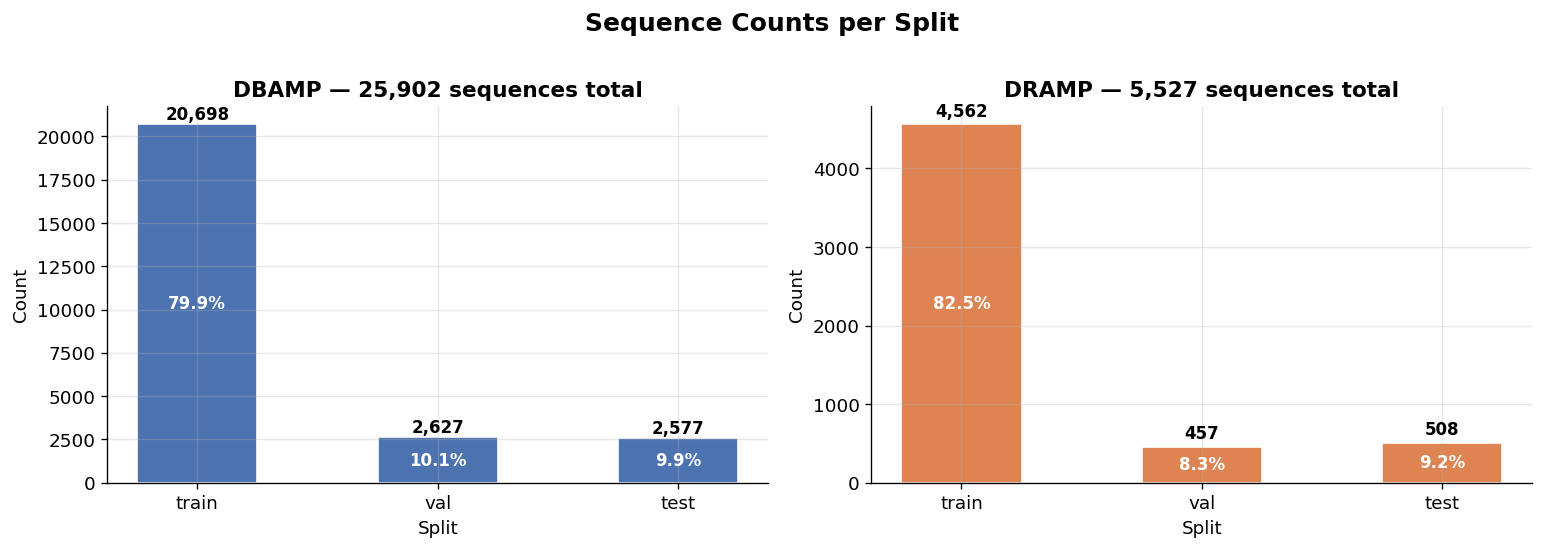

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, src, color in zip(axes, ['DBAMP', 'DRAMP'], [DBAMP_COLOR, DRAMP_COLOR]):
    sizes = [combined.query('source==@src and split==@s').shape[0] for s in SPLITS]
    bars = ax.bar(SPLITS, sizes, color=color, width=0.5, edgecolor='white')
    for bar, v in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 50, f'{v:,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    total = sum(sizes)
    pcts = [f'{v / total * 100:.1f}%' for v in sizes]
    ax.set_title(f'{src} — {total:,} sequences total', fontsize=13, fontweight='bold')
    ax.set_xlabel('Split')
    ax.set_ylabel('Count')
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, pct,
                ha='center', va='center', color='white', fontsize=10, fontweight='bold')

fig.suptitle('Sequence Counts per Split', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

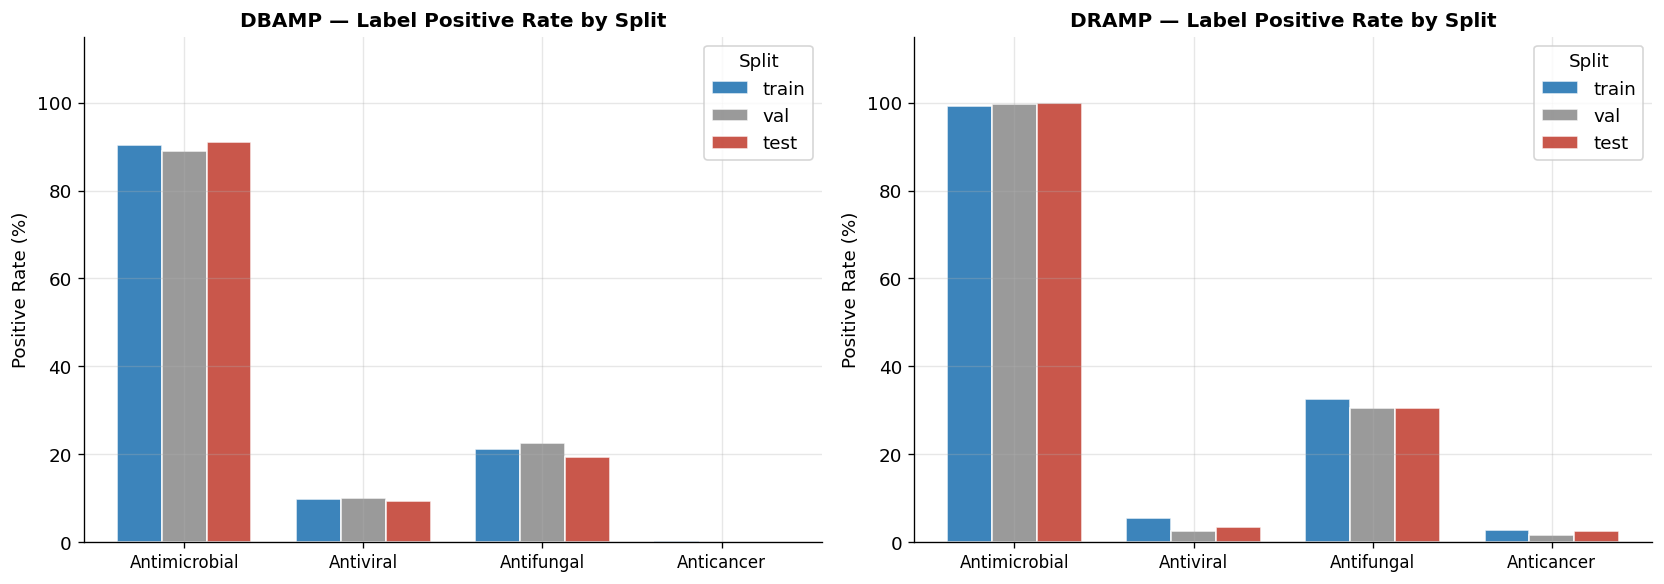

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, src in zip(axes, ['DBAMP', 'DRAMP']):
    pos_rates = {}
    for split in SPLITS:
        df = combined.query('source==@src and split==@split')
        pos_rates[split] = (df[LABELS].mean() * 100).values

    x = np.arange(len(LABELS))
    width = 0.25
    split_colors = ['#1a6faf', '#888', '#c0392b']
    for i, (split, color) in enumerate(zip(SPLITS, split_colors)):
        bars = ax.bar(x + i * width, pos_rates[split], width,
                      label=split, color=color, alpha=0.85, edgecolor='white')

    ax.set_xticks(x + width)
    ax.set_xticklabels([l.capitalize() for l in LABELS], fontsize=10)
    ax.set_ylabel('Positive Rate (%)')
    ax.set_title(f'{src} — Label Positive Rate by Split', fontsize=12, fontweight='bold')
    ax.legend(title='Split')
    ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()

In [7]:
# Tabular summary
rows = []
for src in ['DBAMP', 'DRAMP']:
    for split in SPLITS:
        df = combined.query('source==@src and split==@split')
        row = {'Source': src, 'Split': split, 'N': len(df)}
        for lbl in LABELS:
            row[lbl] = f"{df[lbl].sum():,} ({df[lbl].mean() * 100:.1f}%)"
        rows.append(row)

summary = pd.DataFrame(rows).set_index(['Source', 'Split'])
summary

N   antimicrobial     antiviral     antifungal  anticancer
Source Split                                                                
DBAMP  train  20698  18,681 (90.3%)  2,036 (9.8%)  4,371 (21.1%)   60 (0.3%)
       val     2627   2,339 (89.0%)   265 (10.1%)    591 (22.5%)    3 (0.1%)
       test    2577   2,346 (91.0%)    240 (9.3%)    498 (19.3%)    4 (0.2%)
DRAMP  train   4562   4,525 (99.2%)    255 (5.6%)  1,491 (32.7%)  126 (2.8%)
       val      457     455 (99.6%)     12 (2.6%)    140 (30.6%)    8 (1.8%)
       test     508    508 (100.0%)     18 (3.5%)    155 (30.5%)   13 (2.6%)

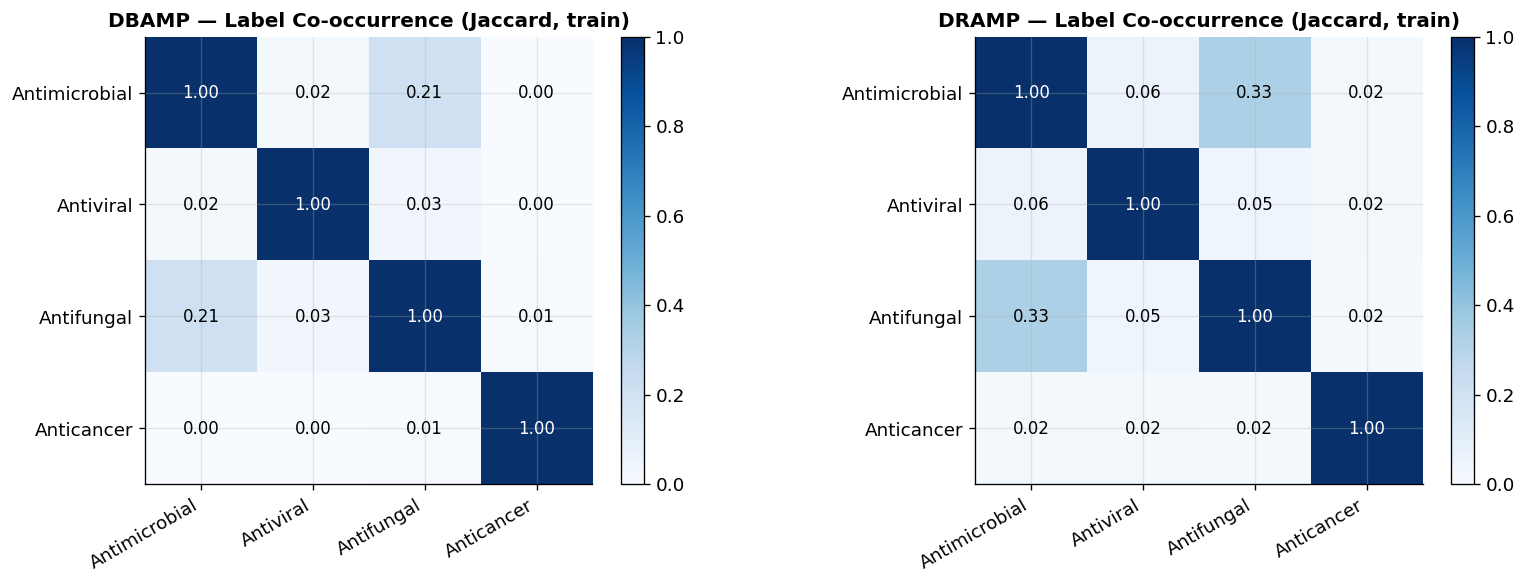

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, src in zip(axes, ['DBAMP', 'DRAMP']):
    train_df = combined.query('source==@src and split=="train"')
    mat = train_df[LABELS].T.dot(train_df[LABELS]).values.astype(float)
    # Normalise by diagonal (Jaccard-like)
    diag = np.diag(mat)
    norm = mat / (diag[:, None] + diag[None, :] - mat + 1e-9)

    im = ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
    labels_cap = [l.capitalize() for l in LABELS]
    ax.set_xticks(range(4));
    ax.set_xticklabels(labels_cap, rotation=30, ha='right')
    ax.set_yticks(range(4));
    ax.set_yticklabels(labels_cap)
    ax.set_title(f'{src} — Label Co-occurrence (Jaccard, train)', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{norm[i, j]:.2f}', ha='center', va='center',
                    color='white' if norm[i, j] > 0.6 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

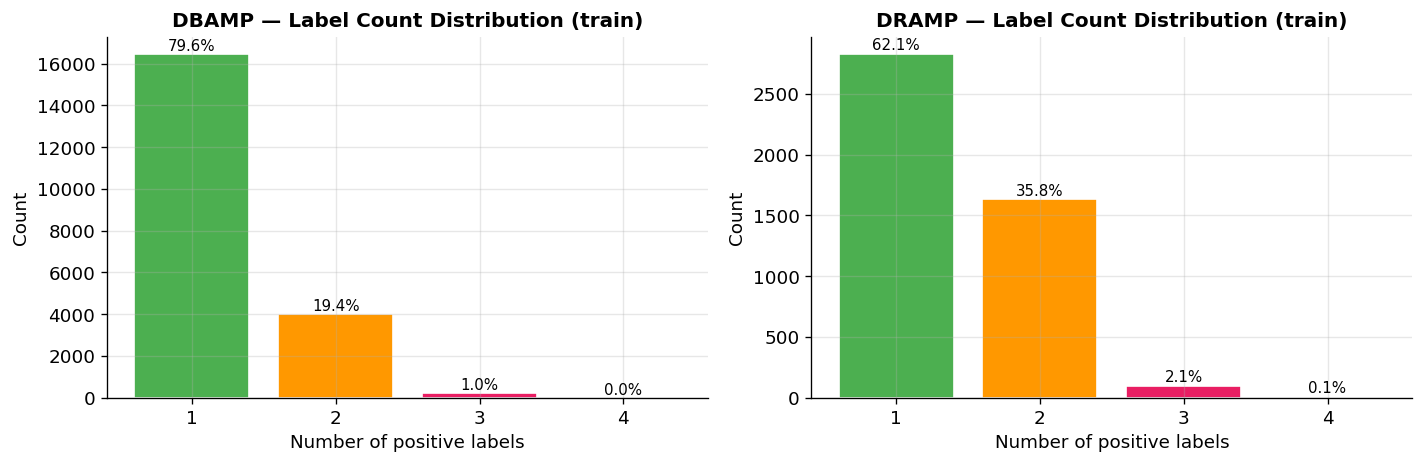

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, src in zip(axes, ['DBAMP', 'DRAMP']):
    train_df = combined.query('source==@src and split=="train"')
    vc = train_df['n_labels'].value_counts().sort_index()
    bars = ax.bar(vc.index, vc.values, color=[LABEL_COLORS[min(i, 3)] for i in vc.index],
                  edgecolor='white')
    for bar, v in zip(bars, vc.values):
        pct = v / len(train_df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, v + 10, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Number of positive labels')
    ax.set_ylabel('Count')
    ax.set_title(f'{src} — Label Count Distribution (train)', fontsize=12, fontweight='bold')
    ax.set_xticks(vc.index)

plt.tight_layout()
plt.show()

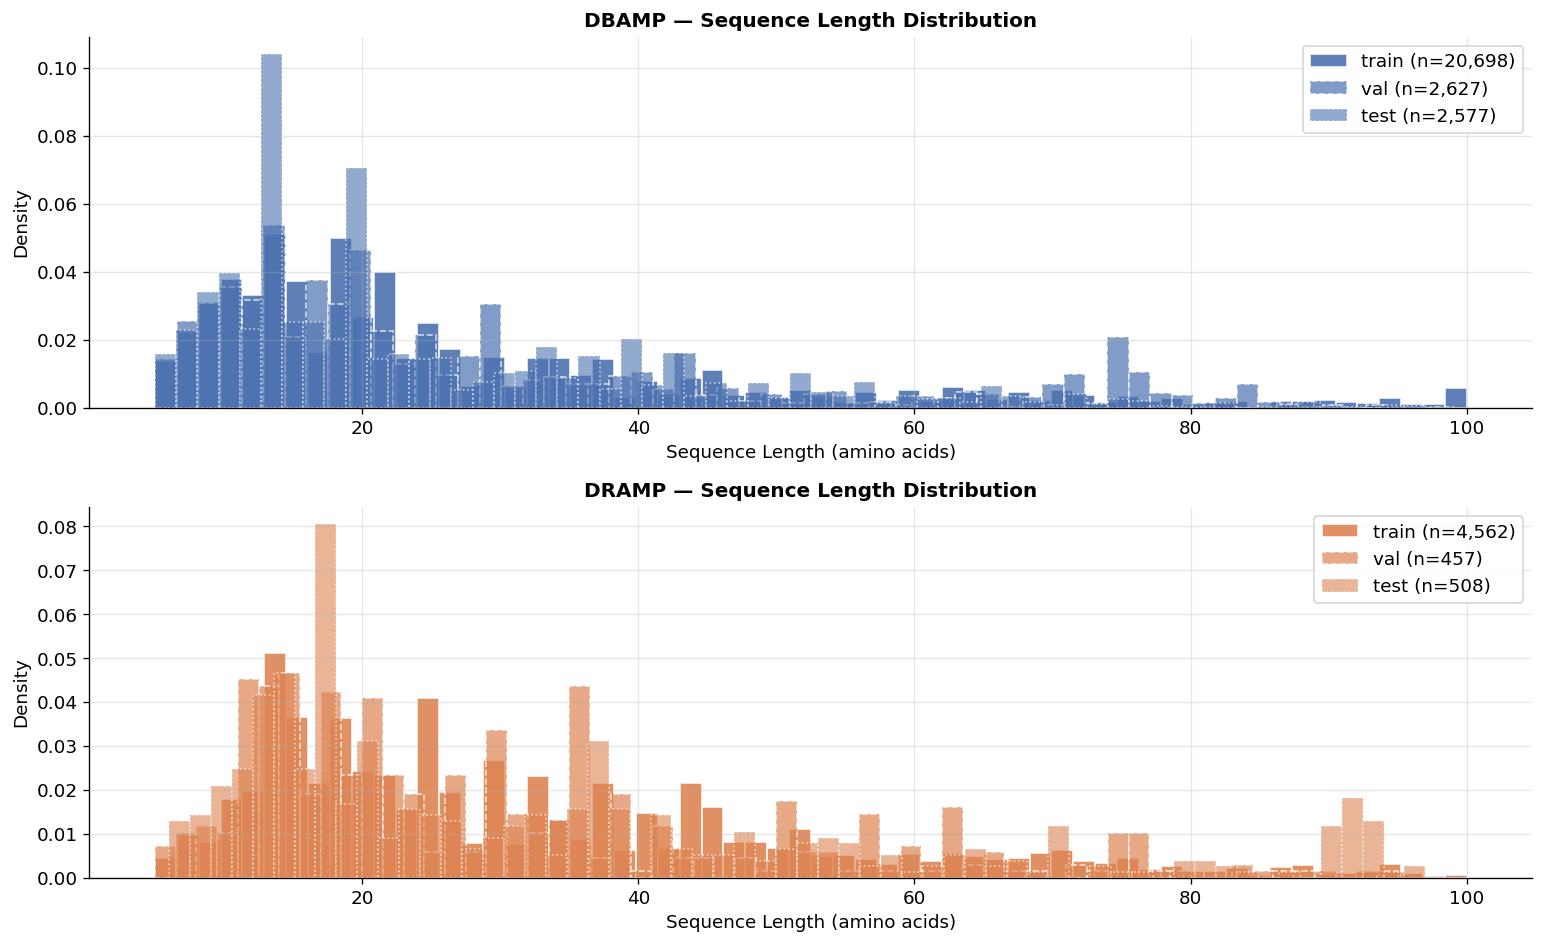

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for ax, src, color in zip(axes, ['DBAMP', 'DRAMP'], [DBAMP_COLOR, DRAMP_COLOR]):
    for split, ls, alpha in zip(SPLITS, ['-', '--', ':'], [0.9, 0.7, 0.6]):
        df = combined.query('source==@src and split==@split')
        ax.hist(df['seq_len'], bins=60, alpha=alpha, linestyle=ls,
                label=f'{split} (n={len(df):,})', color=color,
                edgecolor='white', density=True)
    ax.set_title(f'{src} — Sequence Length Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sequence Length (amino acids)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
print('Sequence length statistics (train splits):')
for src in ['DBAMP', 'DRAMP']:
    df = combined.query('source==@src and split=="train"')
    stats = df['seq_len'].describe(percentiles=[.25, .5, .75, .95])
    print(f'\n{src}:')
    print(stats.to_string())

Sequence length statistics (train splits):

DBAMP:
count    20698.000000
mean        27.959271
std         21.085630
min          5.000000
25%         13.000000
50%         20.000000
75%         36.000000
95%         75.000000
max        100.000000

DRAMP:
count    4562.000000
mean       32.247260
std        19.829879
min         5.000000
25%        17.000000
50%        26.000000
75%        43.000000
95%        74.000000
max       100.000000


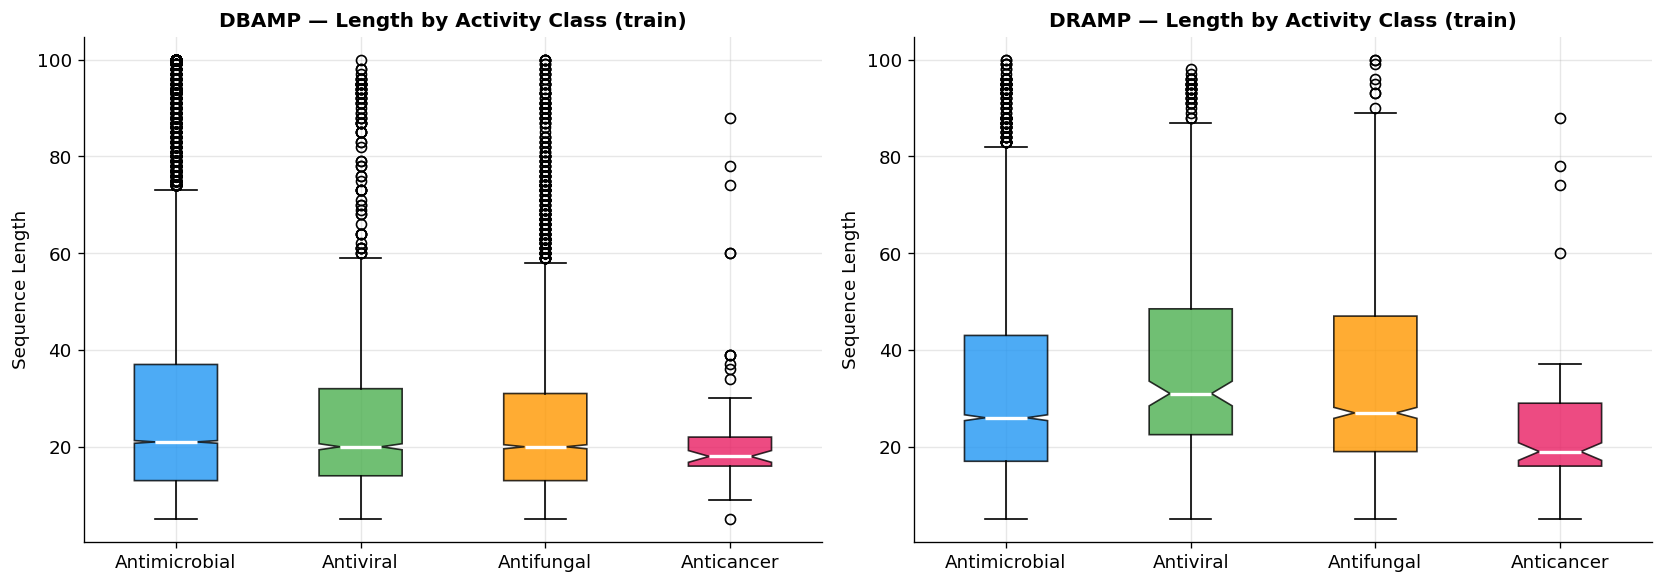

In [12]:
train_all = combined[combined['split'] == 'train'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, src in zip(axes, ['DBAMP', 'DRAMP']):
    df = train_all[train_all['source'] == src]
    plot_data = []
    plot_labels = []
    for lbl, color in zip(LABELS, LABEL_COLORS):
        plot_data.append(df[df[lbl] == 1]['seq_len'].values)
        plot_labels.append(lbl.capitalize())
    bps = ax.boxplot(plot_data, patch_artist=True, notch=True,
                     medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bps['boxes'], LABEL_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(plot_labels)
    ax.set_ylabel('Sequence Length')
    ax.set_title(f'{src} — Length by Activity Class (train)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

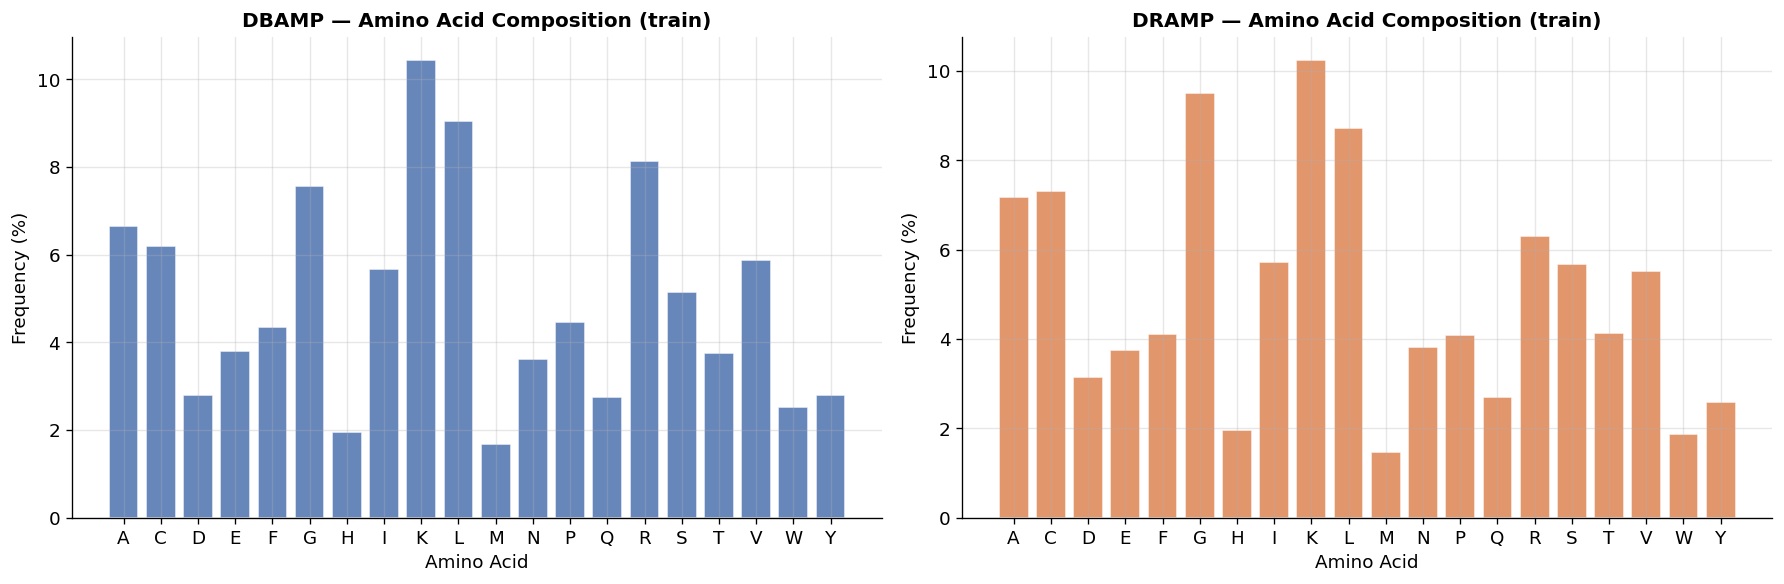

In [13]:
from collections import Counter

AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')


def aa_freq(sequences):
    counter = Counter(''.join(sequences))
    total = sum(counter.values())
    return {aa: counter.get(aa, 0) / total * 100 for aa in AMINO_ACIDS}


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, src, color in zip(axes, ['DBAMP', 'DRAMP'], [DBAMP_COLOR, DRAMP_COLOR]):
    df = combined.query('source==@src and split=="train"')
    freqs = aa_freq(df['sequence'])
    aas = list(freqs.keys())
    vals = list(freqs.values())

    bars = ax.bar(aas, vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Amino Acid')
    ax.set_ylabel('Frequency (%)')
    ax.set_title(f'{src} — Amino Acid Composition (train)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

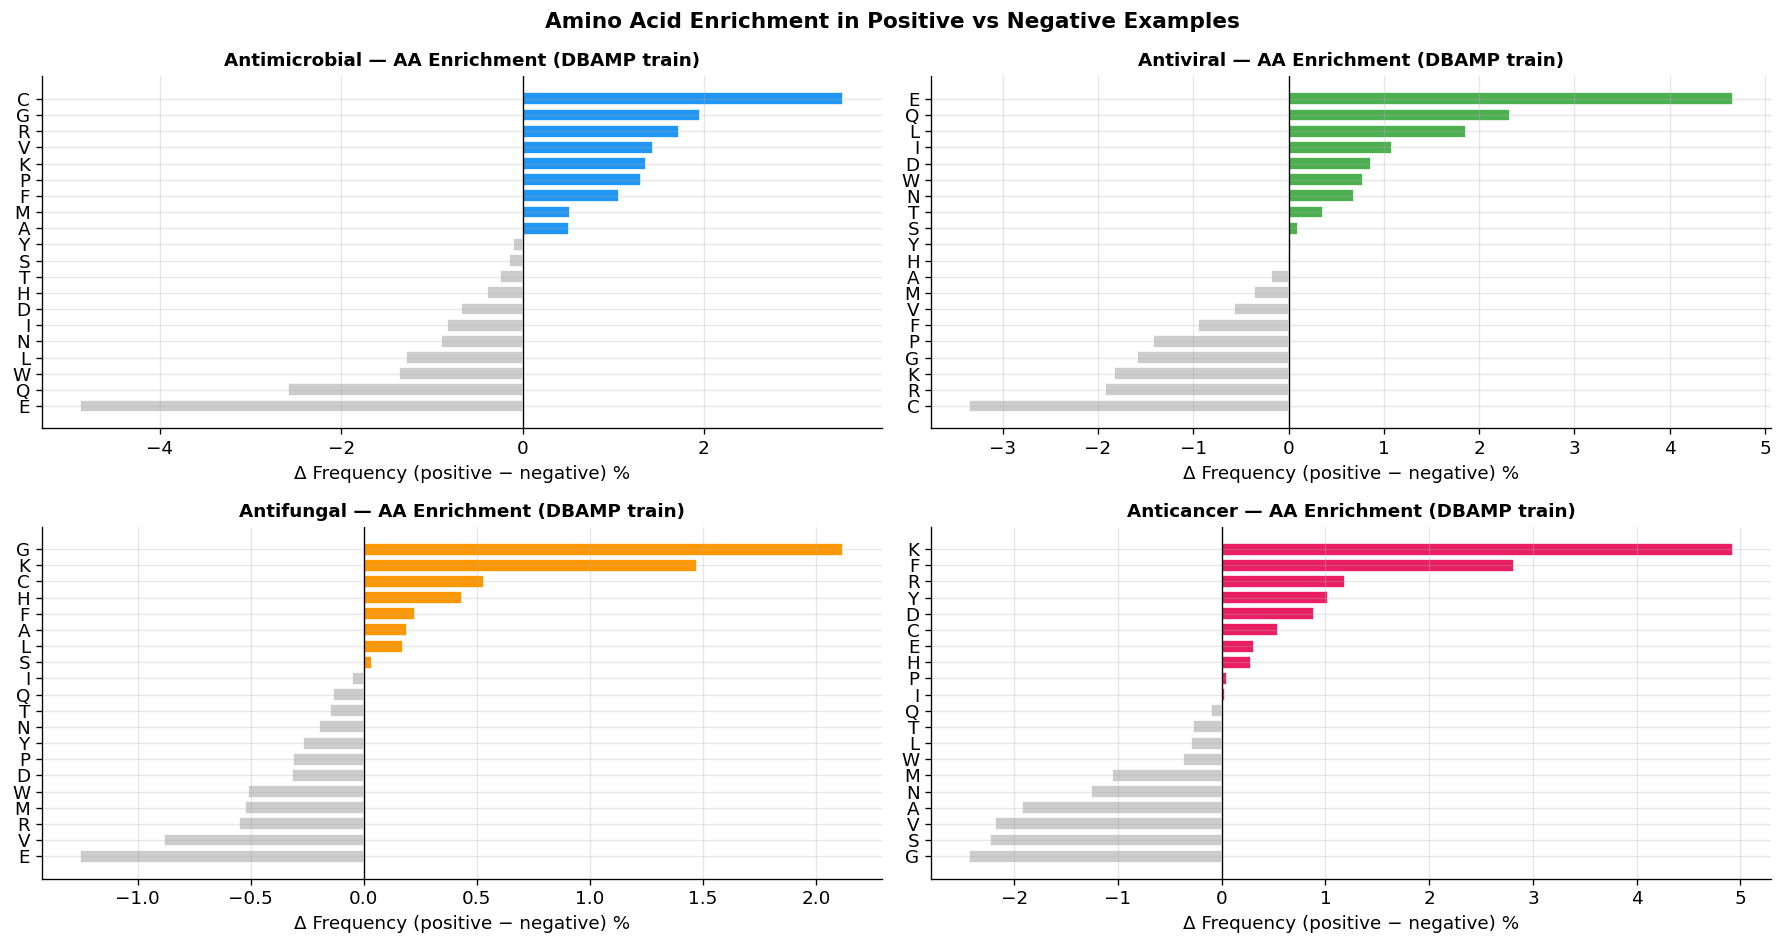

In [14]:
df = combined.query('source=="DBAMP" and split=="train"')
baseline = aa_freq(df['sequence'])

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.flatten()

for ax, lbl, color in zip(axes, LABELS, LABEL_COLORS):
    pos_df = df[df[lbl] == 1]
    neg_df = df[df[lbl] == 0]
    pos_freq = aa_freq(pos_df['sequence'])
    neg_freq = aa_freq(neg_df['sequence'])
    diff = {aa: pos_freq[aa] - neg_freq[aa] for aa in AMINO_ACIDS}
    sorted_aa = sorted(diff, key=diff.get)
    vals = [diff[aa] for aa in sorted_aa]
    colors = [color if v > 0 else '#ccc' for v in vals]
    ax.barh(sorted_aa, vals, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Δ Frequency (positive − negative) %')
    ax.set_title(f'{lbl.capitalize()} — AA Enrichment (DBAMP train)', fontsize=11, fontweight='bold')

plt.suptitle('Amino Acid Enrichment in Positive vs Negative Examples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

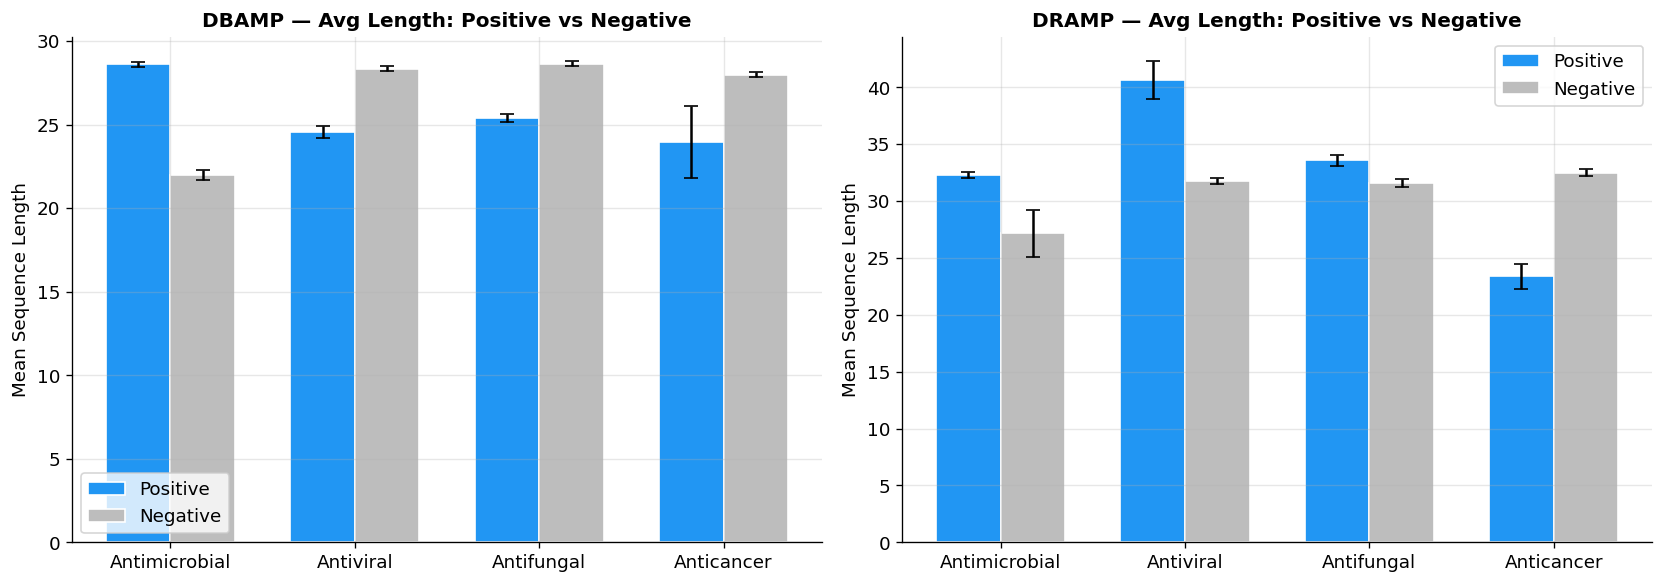

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, src in zip(axes, ['DBAMP', 'DRAMP']):
    df = combined.query('source==@src and split=="train"')
    means = {}
    sems = {}
    for lbl in LABELS:
        pos = df[df[lbl] == 1]['seq_len']
        neg = df[df[lbl] == 0]['seq_len']
        means[lbl] = [pos.mean(), neg.mean()]
        sems[lbl] = [pos.sem(), neg.sem()]

    x = np.arange(len(LABELS))
    width = 0.35
    pos_means = [means[l][0] for l in LABELS]
    neg_means = [means[l][1] for l in LABELS]
    pos_sems = [sems[l][0] for l in LABELS]
    neg_sems = [sems[l][1] for l in LABELS]

    b1 = ax.bar(x - width / 2, pos_means, width, yerr=pos_sems,
                label='Positive', color='#2196F3', capsize=4, edgecolor='white')
    b2 = ax.bar(x + width / 2, neg_means, width, yerr=neg_sems,
                label='Negative', color='#BDBDBD', capsize=4, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels([l.capitalize() for l in LABELS])
    ax.set_ylabel('Mean Sequence Length')
    ax.set_title(f'{src} — Avg Length: Positive vs Negative', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
dbamp_seqs = set(combined[combined['source'] == 'DBAMP']['sequence'])
dramp_seqs = set(combined[combined['source'] == 'DRAMP']['sequence'])
overlap = dbamp_seqs & dramp_seqs
print(f'DBAMP unique sequences  : {len(dbamp_seqs):,}')
print(f'DRAMP unique sequences  : {len(dramp_seqs):,}')
print(f'Overlap (exact match)   : {len(overlap):,}  ({len(overlap) / len(dbamp_seqs) * 100:.2f}% of DBAMP)')

db_train = set(data['dbamp_train']['sequence'])
db_val = set(data['dbamp_val']['sequence'])
db_test = set(data['dbamp_test']['sequence'])
dr_train = set(data['dramp_train']['sequence'])
dr_val = set(data['dramp_val']['sequence'])
dr_test = set(data['dramp_test']['sequence'])

print('\n=== Within-dataset split leakage ===')
print(f'DBAMP train∩val  : {len(db_train & db_val):,}')
print(f'DBAMP train∩test : {len(db_train & db_test):,}')
print(f'DBAMP val∩test   : {len(db_val & db_test):,}')
print(f'DRAMP train∩val  : {len(dr_train & dr_val):,}')
print(f'DRAMP train∩test : {len(dr_train & dr_test):,}')
print(f'DRAMP val∩test   : {len(dr_val & dr_test):,}')

DBAMP unique sequences  : 25,902
DRAMP unique sequences  : 5,527
Overlap (exact match)   : 5,479  (21.15% of DBAMP)

=== Within-dataset split leakage ===
DBAMP train∩val  : 0
DBAMP train∩test : 0
DBAMP val∩test   : 0
DRAMP train∩val  : 0
DRAMP train∩test : 0
DRAMP val∩test   : 0


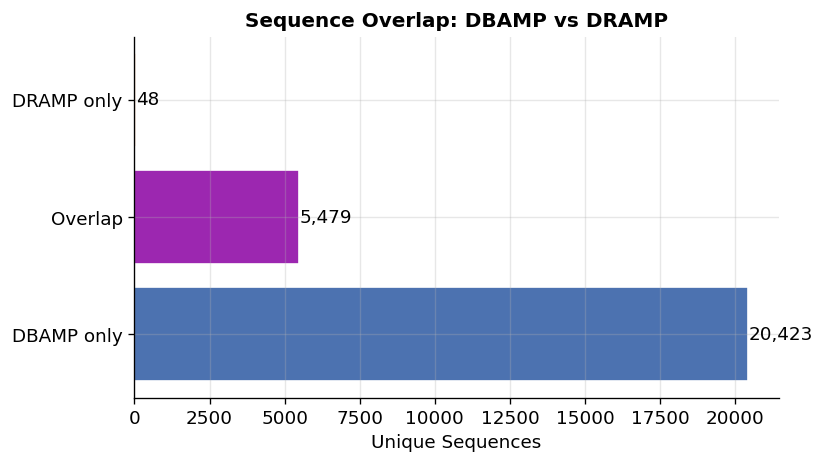

In [17]:
overlap_data = {
    'DBAMP only': len(dbamp_seqs - dramp_seqs),
    'Overlap': len(overlap),
    'DRAMP only': len(dramp_seqs - dbamp_seqs),
}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(list(overlap_data.keys()), list(overlap_data.values()),
               color=[DBAMP_COLOR, '#9C27B0', DRAMP_COLOR], edgecolor='white')
for bar, v in zip(bars, overlap_data.values()):
    ax.text(v + 10, bar.get_y() + bar.get_height() / 2, f'{v:,}', va='center', fontsize=11)
ax.set_xlabel('Unique Sequences')
ax.set_title('Sequence Overlap: DBAMP vs DRAMP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()